## Inleiding

Dit notebook laat een verkennende analyse zien van donateurs- en transactiedata van een fictieve non-profitorganisatie. De gebruikte dataset is publieke mock data van Kaggle: https://www.kaggle.com/datasets/grantstancliff/mock-nonprofit-fundraising-data.

In dit project staat centraal:
- bronbestanden inladen en structureren
- data controleren op kwaliteit
- tabellen samenvoegen en verrijken
- rapportages en eenvoudige visualisaties maken

Het doel is om te laten zien hoe fondsenwervingsdata stap voor stap bruikbaar gemaakt kan worden voor controle, rapportage en verdere analyse.


In [1]:
import warnings
import os
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from IPython.display import display

warnings.filterwarnings('ignore')

# ── Paden ─────────────────────────────────────────────────────────────────────
BASE_DIR    = Path('.')
BRON_DIR    = BASE_DIR / 'data' / 'bron'
BRONZE_DIR  = BASE_DIR / 'data' / 'bronze'
SILVER_DIR  = BASE_DIR / 'data' / 'silver'
GOLD_DIR    = BASE_DIR / 'data' / 'gold'
EXPORT_DIR  = BASE_DIR / 'exports'

for d in [BRONZE_DIR, SILVER_DIR, GOLD_DIR, EXPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Stijl ─────────────────────────────────────────────────────────────────────
ACHTERGROND = '#F7F6F2'
KLEUREN     = ['#20808D', '#A84B2F', '#1B474D', '#944454', '#FFC553', '#848456']
plt.rcParams.update({
    'figure.facecolor': ACHTERGROND,
    'axes.facecolor':   ACHTERGROND,
    'figure.dpi':       150,
    'font.family':      'sans-serif',
})

print('- Bibliotheken geladen')
print(f'  pandas  {pd.__version__}')
print(f'  numpy   {np.__version__}')


- Bibliotheken geladen
  pandas  2.3.3
  numpy   2.4.1


## Data

In deze analyse is gebruikgemaakt van een publieke mock-dataset over fondsenwerving, waaronder:

- transacties
- donateurs
- campagnes
- fondsen
- donor metrics

De data is verwerkt via een medaillon-structuur:
- bronze: ruwe bronbestanden
- silver: verrijkte analysetabel
- gold: samenvattingstabellen voor rapportage en export


In [2]:
# Inlezen bronbestanden en opslaan als bronze Parquet
print('Bronbestanden inlezen')
t0 = datetime.now()

tx   = pd.read_csv(BRON_DIR / 'transactions.csv')
con  = pd.read_csv(BRON_DIR / 'constituents.csv')
camp = pd.read_csv(BRON_DIR / 'campaigns.csv')
app  = pd.read_csv(BRON_DIR / 'appeals.csv')
fn   = pd.read_csv(BRON_DIR / 'funds.csv')
dm   = pd.read_csv(BRON_DIR / 'donor_metrics.csv')

elapsed = (datetime.now() - t0).total_seconds()
print(f'- Ingelezen in {elapsed:.1f}s')
print()

overzicht = {
    'Transacties':    len(tx),
    'Donateurs':      len(con),
    'Campagnes':      len(camp),
    'Appeals':        len(app),
    'Fondsen':        len(fn),
    'Donormetrieken': len(dm),
}
for naam, n in overzicht.items():
    print(f'  {naam:<18}: {n:>6,} rijen')

# ── Opslaan als bronze Parquet ─────────────────────────────────────────────────
tx.to_parquet(BRONZE_DIR / 'transactions.parquet',    index=False)
con.to_parquet(BRONZE_DIR / 'constituents.parquet',   index=False)
camp.to_parquet(BRONZE_DIR / 'campaigns.parquet',     index=False)
app.to_parquet(BRONZE_DIR / 'appeals.parquet',        index=False)
fn.to_parquet(BRONZE_DIR / 'funds.parquet',           index=False)
dm.to_parquet(BRONZE_DIR / 'donor_metrics.parquet',   index=False)

print()
print('- Bronze Parquet opgeslagen')


Bronbestanden inlezen
- Ingelezen in 0.2s

  Transacties       : 55,909 rijen
  Donateurs         :  5,000 rijen
  Campagnes         :     24 rijen
  Appeals           :     70 rijen
  Fondsen           :      8 rijen
  Donormetrieken    :  4,626 rijen

- Bronze Parquet opgeslagen


## Werkwijze

Voordat de data wordt gebruikt voor rapportages, zijn eerst enkele basiscontroles uitgevoerd. Daarbij is onder andere gekeken naar:
- ontbrekende waarden
- dubbele transactie-ID's
- ongeldige of opvallende bedragen
- ontbrekende koppelingen tussen transacties en andere tabellen

Daarna zijn de transacties verrijkt met extra informatie, zoals donateurtype, campagnenaam en donorsegment.


In [ ]:
print('=' * 60)
print('DATAKWALITEITSRAPPORT')
print('=' * 60)

problemen = []

# ── Check 1: Dubbele transactie-ID's ──────────────────────────────────────────
dubbel_tx = tx['transaction_id'].duplicated().sum()
print(f'\n[1] Dubbele transactie-ID\'s : {dubbel_tx}')
if dubbel_tx > 0:
    problemen.append(f'{dubbel_tx} dubbele transactie-ID\'s')
else:
    print('    - Geen duplicaten gevonden')

# ── Check 2: Negatieve of nulbedragen ─────────────────────────────────────────
neg_bedrag = (tx['amount'] <= 0).sum()
print(f'\n[2] Transacties met bedrag ≤ €0 : {neg_bedrag}')
if neg_bedrag > 0:
    problemen.append(f'{neg_bedrag} transacties met negatief of nulbedrag')
    print(tx[tx['amount'] <= 0][['transaction_id', 'date', 'amount']].head())
else:
    print('    - Alle bedragen positief')

# ── Check 3: Uitzonderlijk hoge bedragen (>3x IQR) ────────────────────────────
q1, q3  = tx['amount'].quantile([0.25, 0.75])
iqr     = q3 - q1
grens   = q3 + 3 * iqr
uitsch  = tx[tx['amount'] > grens]
print(f'\n[3] Uitschieters (bedrag > €{grens:,.0f}) : {len(uitsch)}')
if len(uitsch) > 0:
    problemen.append(f'{len(uitsch)} transacties met uitzonderlijk hoog bedrag (> €{grens:,.0f})')
    print(uitsch[['transaction_id', 'date', 'amount', 'payment_method']]
          .sort_values('amount', ascending=False).head(5).to_string(index=False))

# ── Check 4: Transacties zonder geldige donateur ──────────────────────────────
geldige_con = set(con['constituent_id'])
onbekend_con = tx[~tx['constituent_id'].isin(geldige_con)]
print(f'\n[4] Transacties zonder geldige donateur : {len(onbekend_con)}')
if len(onbekend_con) > 0:
    problemen.append(f'{len(onbekend_con)} transacties zonder geldige donateur-ID')
else:
    print('    - Alle transacties gekoppeld aan bekende donateur')

# ── Check 5: Transacties zonder geldige campagne ──────────────────────────────
geldige_camp = set(camp['campaign_id'])
onbekend_camp = tx[~tx['campaign_id'].isin(geldige_camp)]
print(f'\n[5] Transacties zonder geldige campagne : {len(onbekend_camp)}')
if len(onbekend_camp) > 0:
    problemen.append(f'{len(onbekend_camp)} transacties zonder geldige campagne-ID')
else:
    print('    - Alle transacties gekoppeld aan bekende campagne')

# ── Check 6: Transacties zonder geldige fonds ─────────────────────────────────
geldige_fn = set(fn['fund_id'])
onbekend_fn = tx[~tx['fund_id'].isin(geldige_fn)]
print(f'\n[6] Transacties zonder geldig fonds : {len(onbekend_fn)}')
if len(onbekend_fn) > 0:
    problemen.append(f'{len(onbekend_fn)} transacties zonder geldig fonds-ID')
else:
    print('    - Alle transacties gekoppeld aan bekend fonds')

# ── Check 7: Donateurs zonder e-mailadres ─────────────────────────────────────
geen_email = con['email'].isnull().sum()
print(f'\n[7] Donateurs zonder e-mailadres : {geen_email}')
if geen_email > 0:
    problemen.append(f'{geen_email} donateurs zonder e-mailadres')
else:
    print('    - Alle donateurs hebben een e-mailadres')

# ── Check 8: Ontbrekende naam (individuele donateurs) ─────────────────────────
individuen = con[con['type'] == 'Individual']
geen_naam  = individuen[individuen['first_name'].isnull() | individuen['last_name'].isnull()]
print(f'\n[8] Individuen zonder volledige naam : {len(geen_naam)}')
if len(geen_naam) > 0:
    problemen.append(f'{len(geen_naam)} individuele donateurs zonder volledige naam')
else:
    print('    - Alle individuen hebben een volledige naam')

# ── Samenvatting ──────────────────────────────────────────────────────────────
print()
print('=' * 60)
if problemen:
    print(f'   {len(problemen)} aandachtspunt(en) gevonden:')
    for p in problemen:
        print(f'   • {p}')
else:
    print('- Geen datakwaliteitsproblemen gevonden')
print('=' * 60)


DATAKWALITEITSRAPPORT

[1] Dubbele transactie-ID's : 0
    - Geen duplicaten gevonden

[2] Transacties met bedrag ≤ €0 : 0
    - Alle bedragen positief

[3] Uitschieters (bedrag > €3,468) : 7344
 transaction_id       date    amount payment_method
          18549 2024-08-01 696581.14            ACH
           7308 2024-12-14 636840.54          Check
           7328 2024-12-18 604295.54            ACH
           2463 2024-02-26 586107.34          Other
          19147 2024-08-18 581177.46          Check

[4] Transacties zonder geldige donateur : 0
    - Alle transacties gekoppeld aan bekende donateur

[5] Transacties zonder geldige campagne : 0
    - Alle transacties gekoppeld aan bekende campagne

[6] Transacties zonder geldig fonds : 0
    - Alle transacties gekoppeld aan bekend fonds

[7] Donateurs zonder e-mailadres : 0
    - Alle donateurs hebben een e-mailadres

[8] Individuen zonder volledige naam : 0
    - Alle individuen hebben een volledige naam

⚠️  1 aandachtspunt(en) gevonde

## Verrijkte analysetabel

Na de controles zijn de losse tabellen samengevoegd tot een beter bruikbare analysetabel. Hierdoor kan sneller worden gekeken naar patronen in donaties, campagnes, donorsegmenten en betaalmethoden.


In [4]:
# Datums inlezen en verrijkte transactietabel opbouwen
tx['date'] = pd.to_datetime(tx['date'])
tx['jaar']     = tx['date'].dt.year
tx['maand']    = tx['date'].dt.month
tx['kwartaal'] = tx['date'].dt.quarter
tx['seizoen']  = tx['maand'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
     3: 'Lente',  4: 'Lente',  5: 'Lente',
     6: 'Zomer',  7: 'Zomer',  8: 'Zomer',
     9: 'Herfst',10: 'Herfst',11: 'Herfst',
})

# ── Donateur: naam + type ──────────────────────────────────────────────────────
con['donateur_naam'] = con.apply(
    lambda r: r['organization_name']
              if r['type'] == 'Organization'
              else f"{r['first_name']} {r['last_name']}",
    axis=1
)
con_slim = con[['constituent_id', 'type', 'donateur_naam', 'gender', 'state']].copy()
con_slim.columns = ['constituent_id', 'donateur_type', 'donateur_naam', 'gender', 'staat']

# ── Samenvoegen ───────────────────────────────────────────────────────────────
silver = (
    tx
    .merge(con_slim,                                          on='constituent_id', how='left')
    .merge(camp[['campaign_id', 'name', 'type']]
               .rename(columns={'name': 'campagne_naam', 'type': 'campagne_type'}),
           on='campaign_id', how='left')
    .merge(fn[['fund_id', 'name']]
              .rename(columns={'name': 'fonds_naam'}),
           on='fund_id', how='left')
    .merge(app[['appeal_id', 'name', 'type']]
               .rename(columns={'name': 'appeal_naam', 'type': 'appeal_type'}),
           on='appeal_id', how='left')
)

# ── Donorniveau koppelen ───────────────────────────────────────────────────────
silver = silver.merge(
    dm[['constituent_id', 'donor_level', 'retention_status']],
    on='constituent_id', how='left'
)

# ── Opslaan als silver Parquet ─────────────────────────────────────────────────
silver.to_parquet(SILVER_DIR / 'transacties_verrijkt.parquet', index=False)

print(f'- Silver tabel aangemaakt: {len(silver):,} rijen × {len(silver.columns)} kolommen')
print(f'  Kolommen: {list(silver.columns)}')
silver.head(3)


- Silver tabel aangemaakt: 55,909 rijen × 25 kolommen
  Kolommen: ['transaction_id', 'constituent_id', 'appeal_id', 'campaign_id', 'fund_id', 'date', 'amount', 'payment_method', 'type', 'status', 'jaar', 'maand', 'kwartaal', 'seizoen', 'donateur_type', 'donateur_naam', 'gender', 'staat', 'campagne_naam', 'campagne_type', 'fonds_naam', 'appeal_naam', 'appeal_type', 'donor_level', 'retention_status']


,transaction_id,constituent_id,appeal_id,campaign_id,fund_id,date,amount,payment_method,type,status,...,donateur_naam,gender,staat,campagne_naam,campagne_type,fonds_naam,appeal_naam,appeal_type,donor_level,retention_status
0,1,3884,1,1,8,2022-07-05,29.44,Credit Card,Gift,Completed,...,Robert Kennedy,M,IL,Earth Protectors Annual Fund,Annual,Endowment Fund,Phone-a-thon - Earth Protectors Annual Fund,Phone-a-thon,Major,Retained
1,2,77,1,1,8,2022-07-11,4641.92,ACH,Gift,Completed,...,"Taylor, Lane and Bullock",NaN,FL,Earth Protectors Annual Fund,Annual,Endowment Fund,Phone-a-thon - Earth Protectors Annual Fund,Phone-a-thon,Principal,Retained
2,3,2326,1,1,1,2022-07-03,108.46,Credit Card,Gift,Completed,...,Timothy Cole,M,TX,Earth Protectors Annual Fund,Annual,General Operations,Phone-a-thon - Earth Protectors Annual Fund,Phone-a-thon,General,Lapsed


## Rapportages

In deze stap worden samenvattingstabellen gemaakt die bruikbaar zijn voor Excel of verdere analyse. Het doel is om de data niet alleen op te schonen, maar ook overzichtelijk beschikbaar te maken voor rapportage.


In [5]:
df = pd.read_parquet(SILVER_DIR / 'transacties_verrijkt.parquet')

# Gold 1: maandelijkse donatietotalen
gold_maand = (
    df.groupby(['jaar', 'maand'])
    .agg(
        totaal_donaties   = ('amount',          'sum'),
        aantal_transacties= ('transaction_id',  'count'),
        unieke_donateurs  = ('constituent_id',  'nunique'),
        gem_donatie       = ('amount',           'mean'),
    )
    .reset_index()
    .sort_values(['jaar', 'maand'])
)
gold_maand['periode'] = gold_maand['jaar'].astype(str) + '-' + gold_maand['maand'].astype(str).str.zfill(2)
gold_maand.to_parquet(GOLD_DIR / 'gold_maand.parquet', index=False)
print(f'- Gold 1 opgeslagen: maandelijkse totalen ({len(gold_maand)} periodes)')

# ── Gold 2: Campagneresultaten ─────────────────────────────────────────────────
gold_campagne = (
    df.groupby(['campaign_id', 'campagne_naam', 'campagne_type'])
    .agg(
        totaal_donaties   = ('amount',          'sum'),
        aantal_transacties= ('transaction_id',  'count'),
        unieke_donateurs  = ('constituent_id',  'nunique'),
        gem_donatie       = ('amount',           'mean'),
        max_donatie       = ('amount',           'max'),
    )
    .reset_index()
    .sort_values('totaal_donaties', ascending=False)
)
# Doelstelling koppelen
gold_campagne = gold_campagne.merge(
    camp[['campaign_id', 'goal_amount']], on='campaign_id', how='left'
)
gold_campagne['pct_doel_bereikt'] = (
    gold_campagne['totaal_donaties'] / gold_campagne['goal_amount'] * 100
).round(1)
gold_campagne.to_parquet(GOLD_DIR / 'gold_campagne.parquet', index=False)
print(f'- Gold 2 opgeslagen: campagneresultaten ({len(gold_campagne)} campagnes)')

# Gold 3: donorsegmentatie
gold_donor = (
    df.groupby(['constituent_id', 'donateur_naam', 'donateur_type', 'donor_level', 'retention_status'])
    .agg(
        totaal_gegeven    = ('amount',          'sum'),
        aantal_giften     = ('transaction_id',  'count'),
        gem_gift          = ('amount',           'mean'),
        eerste_gift       = ('date',             'min'),
        laatste_gift      = ('date',             'max'),
    )
    .reset_index()
    .sort_values('totaal_gegeven', ascending=False)
)
gold_donor.to_parquet(GOLD_DIR / 'gold_donor.parquet', index=False)
print(f'- Gold 3 opgeslagen: donorsegmentatie ({len(gold_donor):,} donateurs)')

# ── Gold 4: Betaalmethode per jaar ────────────────────────────────────────────
gold_betaal = (
    df.groupby(['jaar', 'payment_method'])
    .agg(
        totaal_donaties   = ('amount',         'sum'),
        aantal_transacties= ('transaction_id', 'count'),
    )
    .reset_index()
)
gold_betaal.to_parquet(GOLD_DIR / 'gold_betaalmethode.parquet', index=False)
print(f'- Gold 4 opgeslagen: betaalmethoden ({len(gold_betaal)} rijen)')


- Gold 1 opgeslagen: maandelijkse totalen (48 periodes)
- Gold 2 opgeslagen: campagneresultaten (24 campagnes)
- Gold 3 opgeslagen: donorsegmentatie (4,626 donateurs)
- Gold 4 opgeslagen: betaalmethoden (25 rijen)


In [6]:
# Export naar Excel voor rapportage en verdere analyse
excel_pad = EXPORT_DIR / 'wkof_rapportage.xlsx'

with pd.ExcelWriter(excel_pad, engine='openpyxl') as writer:
    gold_maand.to_excel(writer,     sheet_name='Maand_totalen',    index=False)
    gold_campagne.to_excel(writer,  sheet_name='Campagnes',        index=False)
    gold_donor.to_excel(writer,     sheet_name='Donorsegmentatie', index=False)
    gold_betaal.to_excel(writer,    sheet_name='Betaalmethoden',   index=False)
    silver.to_excel(writer,         sheet_name='Alle_transacties', index=False)

grootte_kb = excel_pad.stat().st_size / 1024
print(f'- Excel-rapport geëxporteerd: {excel_pad.name} ({grootte_kb:.0f} KB)')
print(f'  Tabbladen: Maand_totalen, Campagnes, Donorsegmentatie, Betaalmethoden, Alle_transacties')


- Excel-rapport geëxporteerd: wkof_rapportage.xlsx (6529 KB)
  Tabbladen: Maand_totalen, Campagnes, Donorsegmentatie, Betaalmethoden, Alle_transacties


## Extra controles

Naast de basisrapportages zijn ook twee extra overzichten gemaakt:
- **Datakwaliteitsoverzicht**: compacte samenvatting van belangrijke controles
- **Reviewlijst transacties**: transacties die extra aandacht kunnen vragen

Deze overzichten sluiten goed aan op het werk van een datamedewerker, omdat ze helpen bij controle en opvolging.


In [7]:
df = pd.read_parquet(SILVER_DIR / 'transacties_verrijkt.parquet')

# Rapportage 1: datakwaliteitsoverzicht
q1, q3 = df['amount'].quantile([0.25, 0.75])
iqr = q3 - q1
grensextra = q3 + 3 * iqr

camp_bron = pd.read_parquet(BRONZE_DIR / 'campaigns.parquet')
camp_window = camp_bron[['campaign_id', 'start_date', 'end_date']].copy()
camp_window['start_date'] = pd.to_datetime(camp_window['start_date'])
camp_window['end_date'] = pd.to_datetime(camp_window['end_date'])

df_q = df.merge(camp_window, on='campaign_id', how='left')
outside_window = ((df_q['date'] < df_q['start_date']) | (df_q['date'] > df_q['end_date'])).sum()

kwaliteitsrapport = pd.DataFrame([
    {"controle": "Dubbele transactie-ID's", "aantal": int(df["transaction_id"].duplicated().sum())},
    {"controle": "Transacties met bedrag <= 0", "aantal": int((df["amount"] <= 0).sum())},
    {"controle": "Transacties boven 3x IQR-grens", "aantal": int((df["amount"] > grensextra).sum())},
    {"controle": "Transacties buiten campagneperiode", "aantal": int(outside_window)},
    {"controle": "Transacties met betaalmethode Other", "aantal": int((df["payment_method"] == "Other").sum())},
])
kwaliteitsrapport['percentage_van_transacties'] = (kwaliteitsrapport['aantal'] / len(df) * 100).round(2)
kwaliteitsrapport.to_parquet(GOLD_DIR / 'gold_datakwaliteit.parquet', index=False)
print('Extra rapport 1 opgeslagen: gold_datakwaliteit.parquet')
display(kwaliteitsrapport)

# Rapportage 2: reviewlijst transacties
review = df_q.copy()
review['flag_hoog_bedrag'] = review['amount'] > grensextra
review['flag_other_betaalmethode'] = review['payment_method'] == 'Other'
review['flag_buiten_campagneperiode'] = (review['date'] < review['start_date']) | (review['date'] > review['end_date'])

review['review_reden'] = review.apply(
    lambda r: ', '.join([
        reden for reden, actief in [
            ('hoog bedrag', r['flag_hoog_bedrag']),
            ('betaalmethode Other', r['flag_other_betaalmethode']),
            ('buiten campagneperiode', r['flag_buiten_campagneperiode']),
        ] if actief
    ]),
    axis=1
)

reviewlijst = review.loc[
    review[['flag_hoog_bedrag', 'flag_other_betaalmethode', 'flag_buiten_campagneperiode']].any(axis=1),
    ['transaction_id', 'date', 'donateur_naam', 'campagne_naam', 'amount', 'payment_method', 'review_reden']
].sort_values(['date', 'amount'], ascending=[False, False])

reviewlijst.to_parquet(GOLD_DIR / 'gold_reviewlijst.parquet', index=False)
print('Extra rapport 2 opgeslagen: gold_reviewlijst.parquet')
display(reviewlijst.head(10))


Extra rapport 1 opgeslagen: gold_datakwaliteit.parquet


,controle,aantal,percentage_van_transacties
0,Dubbele transactie-ID's,0,0.00
1,Transacties met bedrag <= 0,0,0.00
2,Transacties boven 3x IQR-grens,7344,13.14
3,Transacties buiten campagneperiode,116,0.21
4,Transacties met betaalmethode Other,1336,2.39


Extra rapport 2 opgeslagen: gold_reviewlijst.parquet


,transaction_id,date,donateur_naam,campagne_naam,amount,payment_method,review_reden
36908,36909,2025-05-26,"Campbell, Fisher and Edwards",Trail Blazer 5K Run/Walk,6792.870,ACH,hoog bedrag
37425,37426,2025-05-26,Emily Sandoval,Trail Blazer 5K Run/Walk,3691.040,Check,hoog bedrag
36801,36802,2025-05-25,Shannon Elliott,Trail Blazer 5K Run/Walk,32895.520,ACH,hoog bedrag
37504,37505,2025-05-25,"Rubio, Larsen and Daniels",Trail Blazer 5K Run/Walk,11979.020,Check,hoog bedrag
36909,36910,2025-05-25,"Campbell, Fisher and Edwards",Trail Blazer 5K Run/Walk,9903.026,ACH,hoog bedrag
36827,36828,2025-05-24,Martin and Sons,Trail Blazer 5K Run/Walk,51681.220,ACH,hoog bedrag
37023,37024,2025-05-24,Castro Group,Trail Blazer 5K Run/Walk,12067.220,Check,hoog bedrag
36980,36981,2025-05-24,Hess-Johnson,Trail Blazer 5K Run/Walk,8858.220,Check,hoog bedrag
36997,36998,2025-05-24,Cynthia Holland,Trail Blazer 5K Run/Walk,7824.280,Credit Card,hoog bedrag
37254,37255,2025-05-24,Atkins-Cohen,Trail Blazer 5K Run/Walk,7791.260,ACH,hoog bedrag


## Donaties per maand

Onderstaande grafiek laat zien hoe het totaal aan donaties zich per maand ontwikkelt. Dit is een eenvoudige eerste rapportage om verloop, pieken en dalen in de tijd te zien.


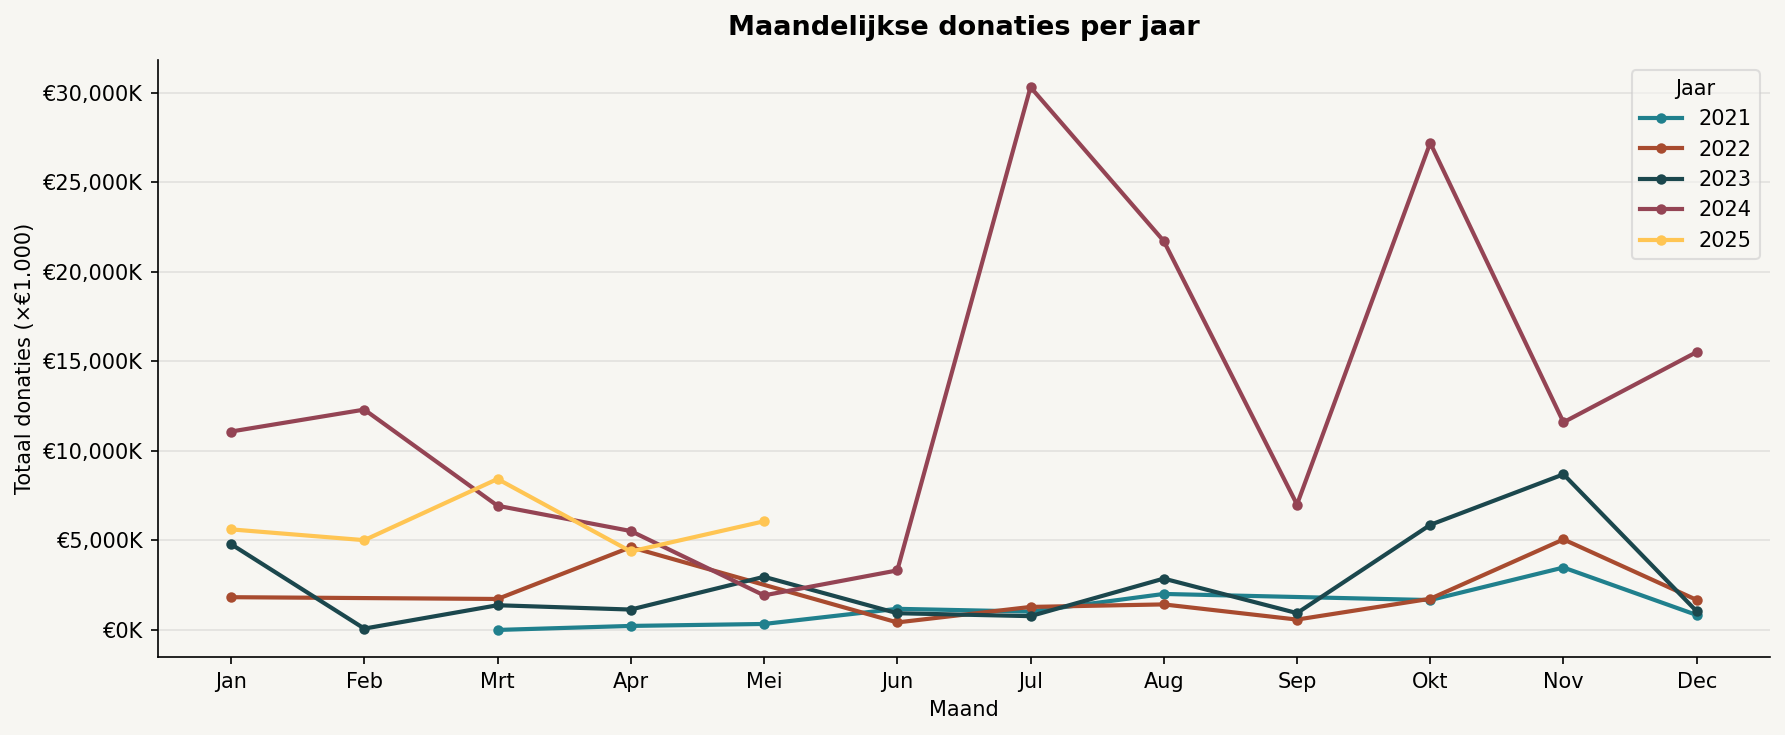

- Grafiek 1 opgeslagen


In [8]:
# Visualisatie 1: maandelijkse donaties per jaar
gold_maand = pd.read_parquet(GOLD_DIR / 'gold_maand.parquet')

jaren = sorted(gold_maand['jaar'].unique())
fig, ax = plt.subplots(figsize=(12, 5))

for i, jaar in enumerate(jaren):
    sub = gold_maand[gold_maand['jaar'] == jaar].sort_values('maand')
    ax.plot(
        sub['maand'], sub['totaal_donaties'] / 1000,
        color=KLEUREN[i % len(KLEUREN)], linewidth=2.0,
        marker='o', markersize=4, label=str(jaar)
    )

maandnamen = ['Jan','Feb','Mrt','Apr','Mei','Jun','Jul','Aug','Sep','Okt','Nov','Dec']
ax.set_xticks(range(1, 13))
ax.set_xticklabels(maandnamen)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}K'))
ax.set_title('Maandelijkse donaties per jaar', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Maand')
ax.set_ylabel('Totaal donaties (×€1.000)')
ax.legend(title='Jaar', framealpha=0.6)
ax.grid(axis='y', alpha=0.3)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(EXPORT_DIR / 'vis1_maand_totalen.png', dpi=150, bbox_inches='tight')
plt.show()
print('- Grafiek 1 opgeslagen')


Observaties:
- De maandtotalen verschillen duidelijk door de tijd heen.
- In sommige perioden zijn er pieken zichtbaar die mogelijk samenhangen met campagnes of grotere giften.
- Dit soort overzichten is bruikbaar als eerste rapportage voor monitoring.


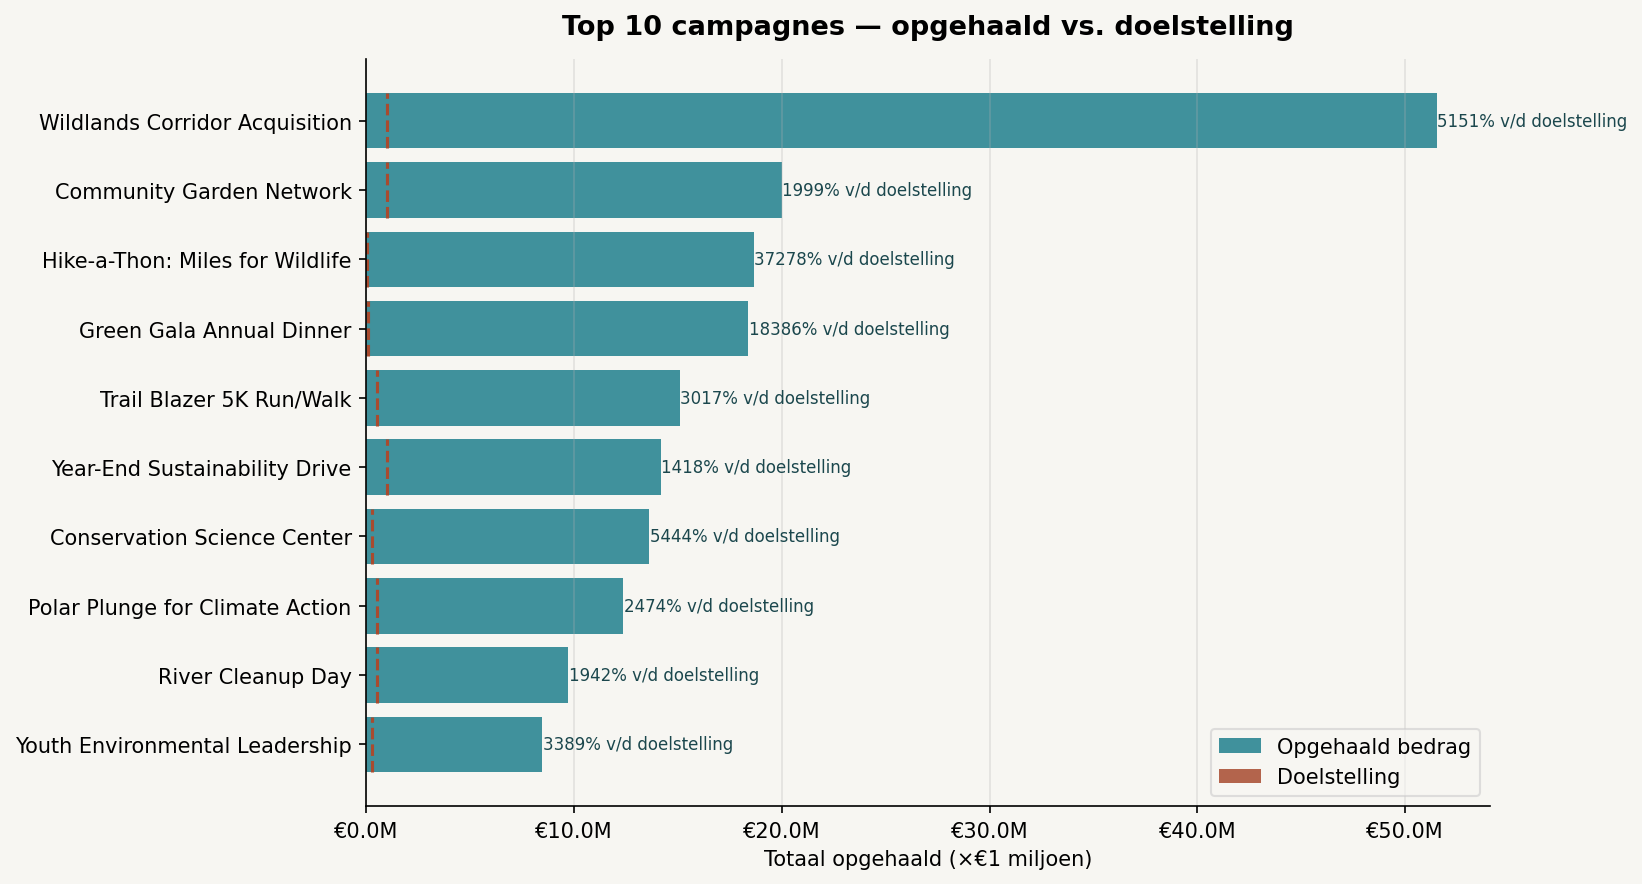

- Grafiek 2 opgeslagen


In [9]:
# Visualisatie 2: top 10 campagnes op totaal opgehaald bedrag
gold_campagne = pd.read_parquet(GOLD_DIR / 'gold_campagne.parquet')

top10 = gold_campagne.nlargest(10, 'totaal_donaties').sort_values('totaal_donaties')

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    top10['campagne_naam'], top10['totaal_donaties'] / 1_000_000,
    color=KLEUREN[0], alpha=0.85
)

# Doelstelling als stippellijn
for i, (_, row) in enumerate(top10.iterrows()):
    doel = row['goal_amount'] / 1_000_000
    ax.plot([doel, doel], [i - 0.4, i + 0.4],
            color=KLEUREN[1], linewidth=1.5, linestyle='--')

# Percentage labels
for bar, (_, row) in zip(bars, top10.iterrows()):
    pct = row['pct_doel_bereikt']
    kleur = KLEUREN[2] if pct >= 100 else KLEUREN[1]
    ax.text(
        bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
        f'{pct:.0f}% v/d doelstelling',
        va='center', fontsize=8, color=kleur
    )

legenda = [
    Patch(facecolor=KLEUREN[0], alpha=0.85, label='Opgehaald bedrag'),
    Patch(facecolor=KLEUREN[1], alpha=0.85, label='Doelstelling'),
]
ax.legend(handles=legenda, loc='lower right', framealpha=0.6)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:.1f}M'))
ax.set_title('Top 10 campagnes — opgehaald vs. doelstelling', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Totaal opgehaald (×€1 miljoen)')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(EXPORT_DIR / 'vis2_campagnes.png', dpi=150, bbox_inches='tight')
plt.show()
print('- Grafiek 2 opgeslagen')


Observaties:
- De vergelijking tussen doelstelling en opbrengst maakt campagnes snel onderling vergelijkbaar.
- Zo wordt zichtbaar welke campagnes relatief veel hebben opgebracht.
- Dit is een nuttige rapportage voor evaluatie en opvolging.


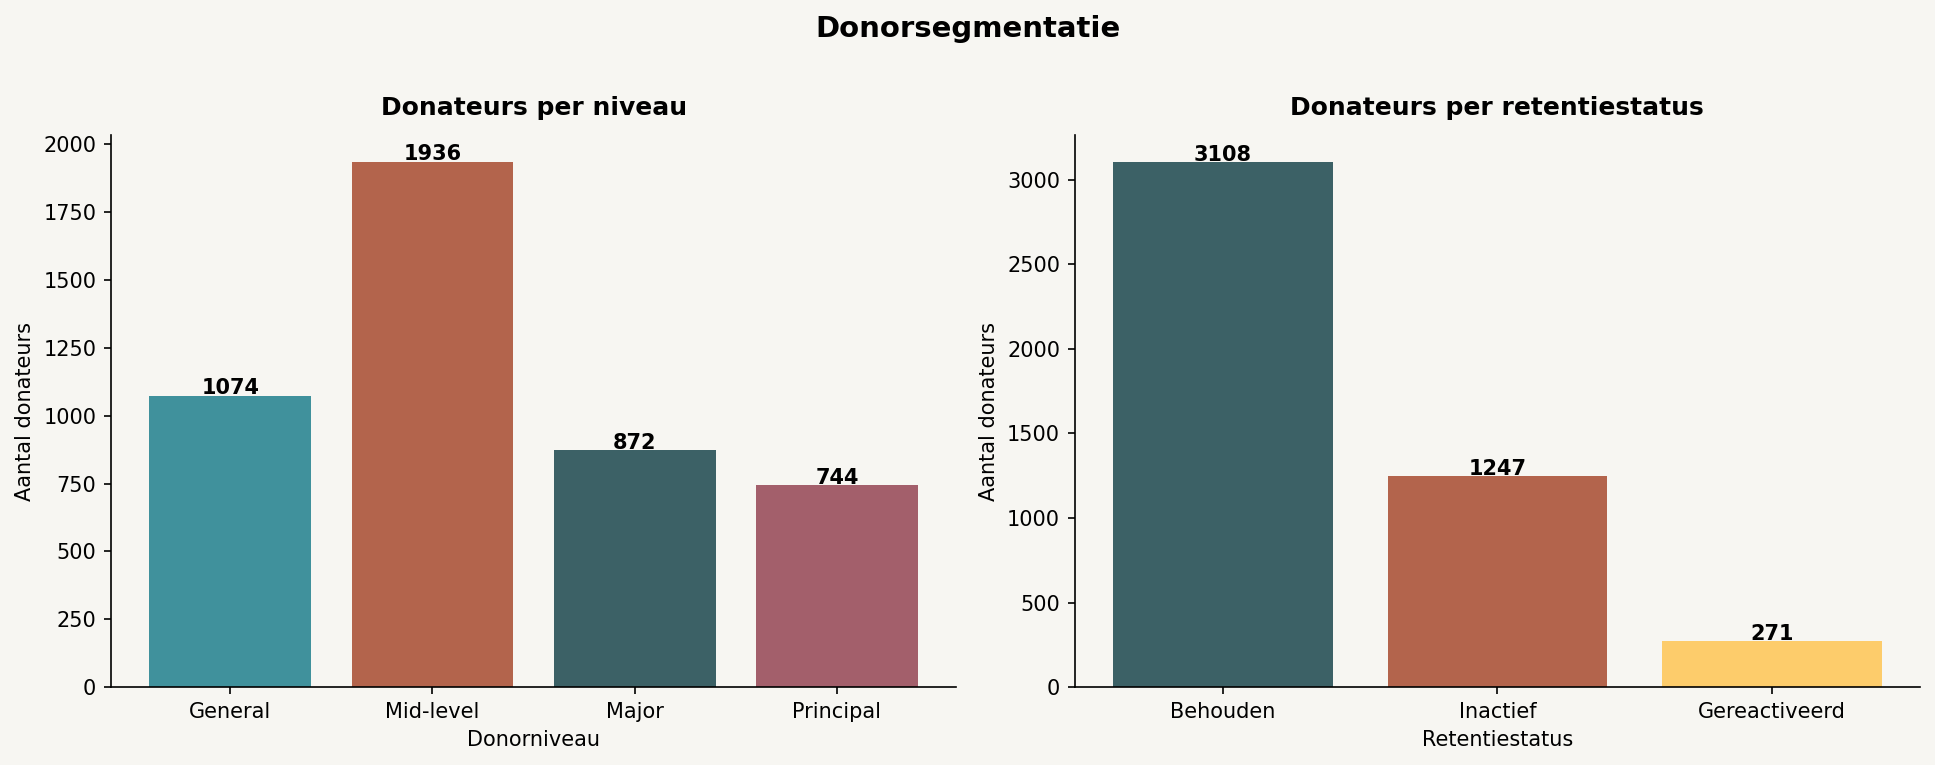

- Grafiek 3 opgeslagen


In [10]:
# Visualisatie 3: donorsegmentatie naar niveau en retentiestatus
gold_donor = pd.read_parquet(GOLD_DIR / 'gold_donor.parquet')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Links: donorniveau
niveau_volgorde = ['General', 'Mid-level', 'Major', 'Principal']
niveau_aantallen = gold_donor['donor_level'].value_counts().reindex(niveau_volgorde, fill_value=0)
axes[0].bar(
    niveau_aantallen.index, niveau_aantallen.values,
    color=KLEUREN[:len(niveau_volgorde)], alpha=0.85
)
for i, (naam, n) in enumerate(niveau_aantallen.items()):
    axes[0].text(i, n + 5, str(n), ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Donateurs per niveau', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Donorniveau')
axes[0].set_ylabel('Aantal donateurs')
for spine in ['top', 'right']:
    axes[0].spines[spine].set_visible(False)

# Rechts: retentiestatus
ret_volgorde = ['Retained', 'Lapsed', 'Reactivated']
ret_nl       = {'Retained': 'Behouden', 'Lapsed': 'Inactief', 'Reactivated': 'Gereactiveerd'}
ret_aantallen = gold_donor['retention_status'].value_counts().reindex(ret_volgorde, fill_value=0)
axes[1].bar(
    [ret_nl[s] for s in ret_aantallen.index], ret_aantallen.values,
    color=[KLEUREN[2], KLEUREN[1], KLEUREN[4]], alpha=0.85
)
for i, n in enumerate(ret_aantallen.values):
    axes[1].text(i, n + 5, str(n), ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Donateurs per retentiestatus', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Retentiestatus')
axes[1].set_ylabel('Aantal donateurs')
for spine in ['top', 'right']:
    axes[1].spines[spine].set_visible(False)

fig.suptitle('Donorsegmentatie', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(EXPORT_DIR / 'vis3_donorsegmentatie.png', dpi=150, bbox_inches='tight')
plt.show()
print('- Grafiek 3 opgeslagen')


Observaties:
- Donateurs verschillen duidelijk in niveau en retentiestatus.
- Deze segmentatie helpt om groepen donateurs beter uit elkaar te houden in rapportages.
- Voor fondsenwerving kan dit helpen bij prioritering van opvolging.


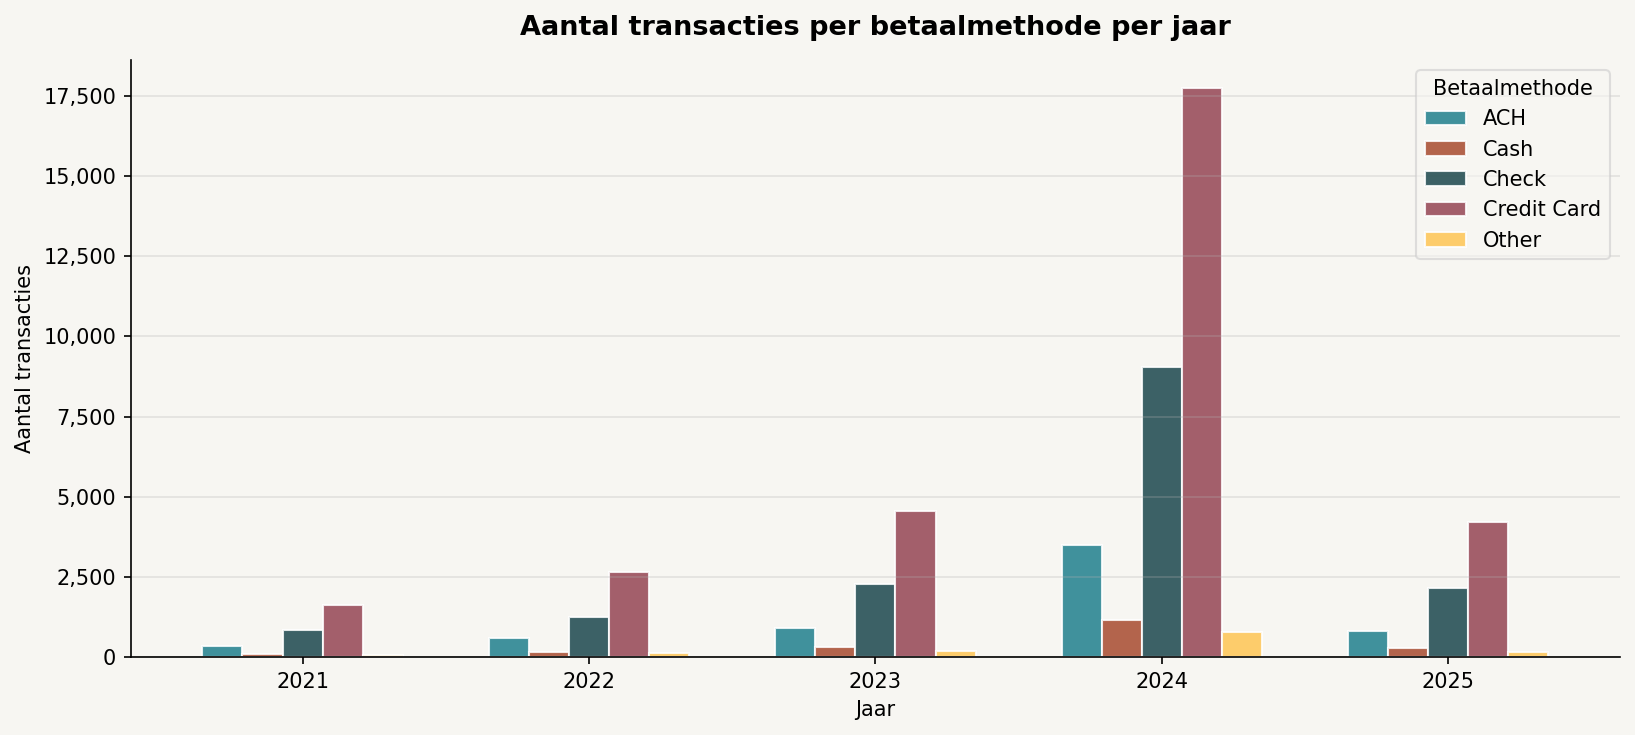

- Grafiek 4 opgeslagen


In [11]:
# Visualisatie 4: betaalmethoden per jaar
gold_betaal = pd.read_parquet(GOLD_DIR / 'gold_betaalmethode.parquet')

pivot = gold_betaal.pivot_table(
    index='jaar', columns='payment_method',
    values='aantal_transacties', aggfunc='sum', fill_value=0
)

fig, ax = plt.subplots(figsize=(11, 5))
pivot.plot(
    kind='bar', ax=ax, color=KLEUREN[:len(pivot.columns)],
    alpha=0.85, width=0.7, edgecolor='white'
)
ax.set_title('Aantal transacties per betaalmethode per jaar',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Jaar')
ax.set_ylabel('Aantal transacties')
ax.set_xticklabels(pivot.index, rotation=0)
ax.legend(title='Betaalmethode', framealpha=0.6)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='y', alpha=0.3)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(EXPORT_DIR / 'vis4_betaalmethoden.png', dpi=150, bbox_inches='tight')
plt.show()
print('- Grafiek 4 opgeslagen')


Observaties:
- Betaalmethoden zijn praktisch relevant voor verwerking en controle.
- De grafiek laat zien welke betaalmethoden het vaakst voorkomen.
- Dit kan helpen bij operationele rapportages en bij het signaleren van afwijkingen.


## Verdiepende analyses

De basisrapportages geven al een eerste beeld. In deze extra stap kijk ik iets dieper naar verschillen tussen typen donateurs, donorsegmenten en betaalmethoden.


### Donateurtype en betaalmethode

Hier kijk ik of individuele donateurs en organisaties andere betaalmethoden gebruiken.


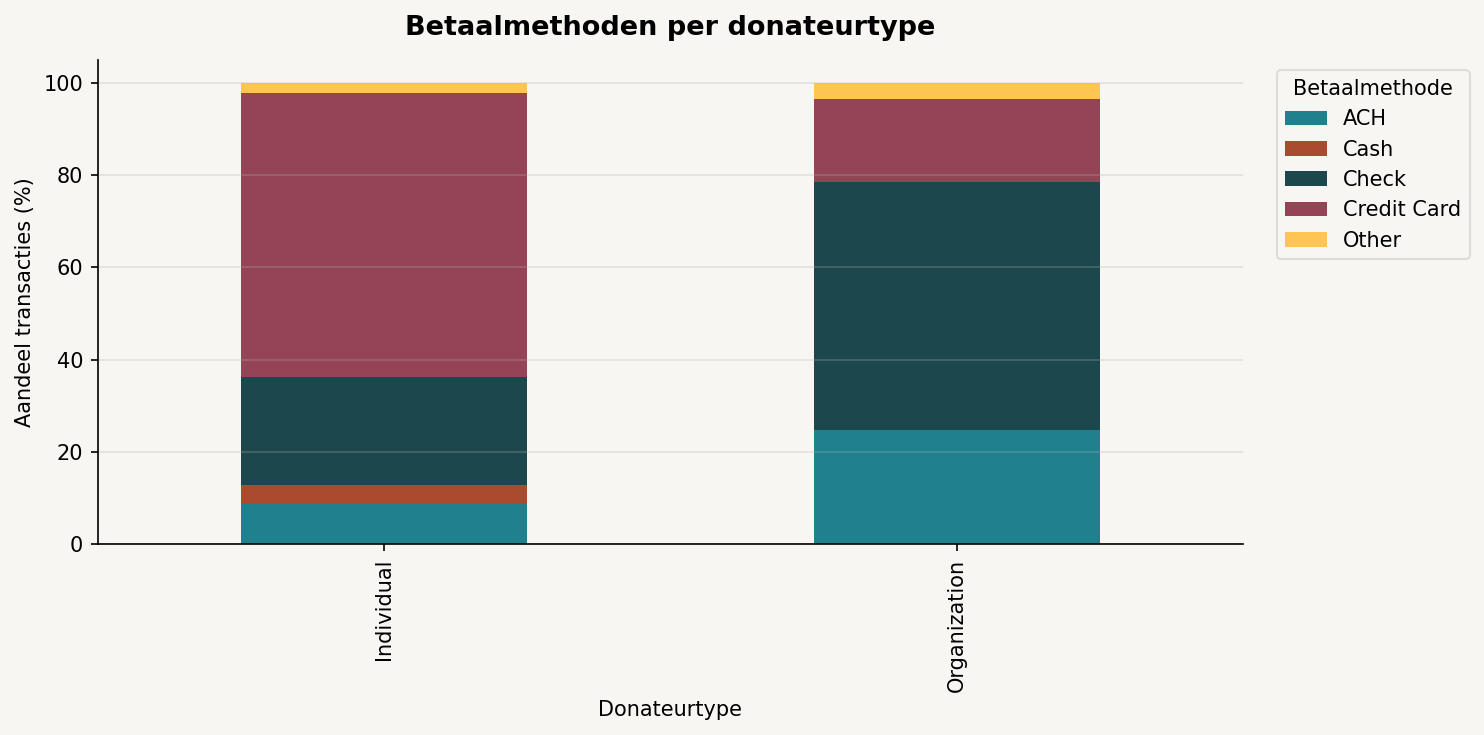

payment_method,ACH,Cash,Check,Credit Card,Other
donateur_type,,,,,
Individual,8.6,4.3,23.3,61.6,2.2
Organization,24.8,0.0,53.8,18.0,3.4


In [12]:
df_verdieping = pd.read_parquet(SILVER_DIR / 'transacties_verrijkt.parquet').copy()

betaalmethode_per_type = pd.crosstab(
    df_verdieping['donateur_type'],
    df_verdieping['payment_method'],
    normalize='index'
).mul(100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
betaalmethode_per_type.plot(kind='bar', stacked=True, ax=ax, color=KLEUREN[:len(betaalmethode_per_type.columns)])
ax.set_title('Betaalmethoden per donateurtype', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Donateurtype')
ax.set_ylabel('Aandeel transacties (%)')
ax.legend(title='Betaalmethode', framealpha=0.6, bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(EXPORT_DIR / 'vis5_betaalmethoden_donateurtype.png', dpi=150, bbox_inches='tight')
plt.show()

display(betaalmethode_per_type)


Observaties:
- Individuele donateurs gebruiken in deze dataset vooral `Credit Card`.
- Organisaties gebruiken relatief vaker `Check` en `ACH`.
- Dat verschil is relevant voor verwerking en rapportage.


### Donateurtype en giftgrootte

Hier vergelijk ik giftgrootte tussen individuele donateurs en organisaties.


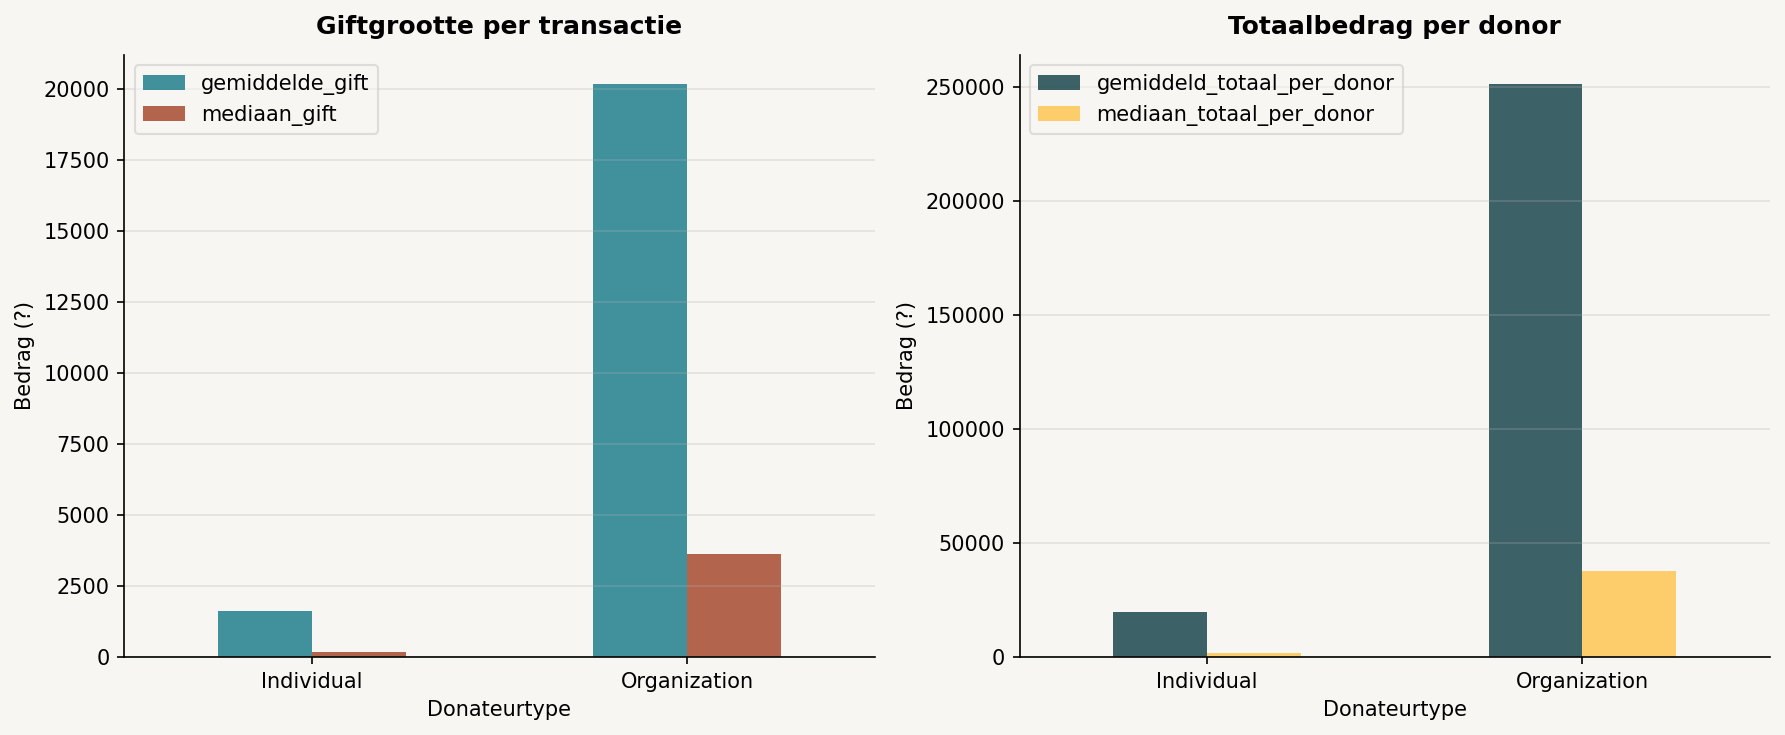

,gemiddelde_gift,mediaan_gift,totaal,transacties
donateur_type,,,,
Individual,1638.09,170.86,7.790581e+07,47559
Organization,20200.16,3644.09,1.686713e+08,8350


,gemiddeld_totaal_per_donor,mediaan_totaal_per_donor,gemiddeld_aantal_transacties
donateur_type,,,
Individual,19693.08,1891.87,12.02
Organization,251748.25,37833.76,12.46


In [13]:
gift_per_type = df_verdieping.groupby('donateur_type').agg(
    gemiddelde_gift=('amount', 'mean'),
    mediaan_gift=('amount', 'median'),
    totaal=('amount', 'sum'),
    transacties=('transaction_id', 'count')
).round(2)

per_donor_type = df_verdieping.groupby(['constituent_id', 'donateur_type']).agg(
    totaal_gegeven=('amount', 'sum'),
    aantal_transacties=('transaction_id', 'count')
).reset_index()

per_donor_type_summary = per_donor_type.groupby('donateur_type').agg(
    gemiddeld_totaal_per_donor=('totaal_gegeven', 'mean'),
    mediaan_totaal_per_donor=('totaal_gegeven', 'median'),
    gemiddeld_aantal_transacties=('aantal_transacties', 'mean')
).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

gift_per_type[['gemiddelde_gift', 'mediaan_gift']].plot(kind='bar', ax=axes[0], color=[KLEUREN[0], KLEUREN[1]], alpha=0.85)
axes[0].set_title('Giftgrootte per transactie', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Donateurtype')
axes[0].set_ylabel('Bedrag (?)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend(framealpha=0.6)
for spine in ['top', 'right']:
    axes[0].spines[spine].set_visible(False)

per_donor_type_summary[['gemiddeld_totaal_per_donor', 'mediaan_totaal_per_donor']].plot(kind='bar', ax=axes[1], color=[KLEUREN[2], KLEUREN[4]], alpha=0.85)
axes[1].set_title('Totaalbedrag per donor', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Donateurtype')
axes[1].set_ylabel('Bedrag (?)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend(framealpha=0.6)
for spine in ['top', 'right']:
    axes[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(EXPORT_DIR / 'vis6_giftgrootte_donateurtype.png', dpi=150, bbox_inches='tight')
plt.show()

display(gift_per_type)
display(per_donor_type_summary)


Observaties:
- Organisaties geven in deze dataset duidelijk grotere bedragen dan individuele donateurs.
- Dat verschil is zichtbaar per transactie en ook per donor.
- Segmentatie naar donateurtype is daarom zinvol.


### Donor level en giftgrootte

Hier kijk ik of de donor levels ook echt verschillen in giftgrootte.


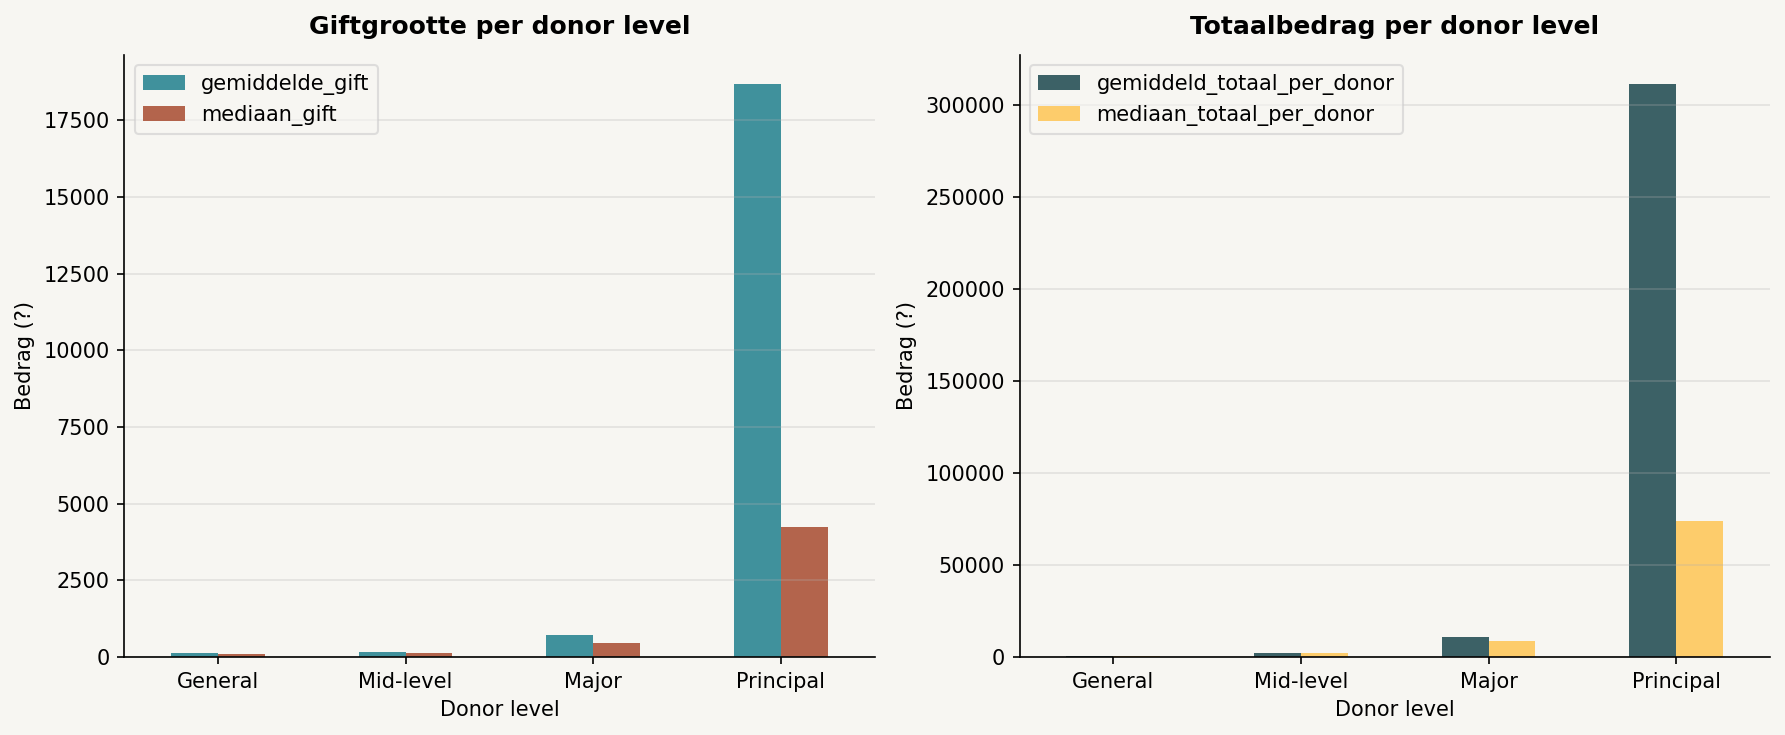

,gemiddelde_gift,mediaan_gift,transacties
donor_level,,,
General,127.64,107.16,4811
Mid-level,173.77,128.98,25415
Major,727.10,446.06,13277
Principal,18691.99,4230.86,12406


,gemiddeld_totaal_per_donor,mediaan_totaal_per_donor
donor_level,,
General,571.75,602.16
Mid-level,2281.21,1963.48
Major,11070.84,8912.31
Principal,311683.97,74196.80


In [14]:
niveau_volgorde = ['General', 'Mid-level', 'Major', 'Principal']

gift_per_level = df_verdieping.groupby('donor_level').agg(
    gemiddelde_gift=('amount', 'mean'),
    mediaan_gift=('amount', 'median'),
    transacties=('transaction_id', 'count')
).reindex(niveau_volgorde).round(2)

per_donor_level = df_verdieping.groupby(['constituent_id', 'donor_level']).agg(
    totaal_gegeven=('amount', 'sum')
).reset_index()

per_donor_level_summary = per_donor_level.groupby('donor_level').agg(
    gemiddeld_totaal_per_donor=('totaal_gegeven', 'mean'),
    mediaan_totaal_per_donor=('totaal_gegeven', 'median')
).reindex(niveau_volgorde).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

gift_per_level[['gemiddelde_gift', 'mediaan_gift']].plot(kind='bar', ax=axes[0], color=[KLEUREN[0], KLEUREN[1]], alpha=0.85)
axes[0].set_title('Giftgrootte per donor level', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Donor level')
axes[0].set_ylabel('Bedrag (?)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend(framealpha=0.6)
for spine in ['top', 'right']:
    axes[0].spines[spine].set_visible(False)

per_donor_level_summary[['gemiddeld_totaal_per_donor', 'mediaan_totaal_per_donor']].plot(kind='bar', ax=axes[1], color=[KLEUREN[2], KLEUREN[4]], alpha=0.85)
axes[1].set_title('Totaalbedrag per donor level', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Donor level')
axes[1].set_ylabel('Bedrag (?)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend(framealpha=0.6)
for spine in ['top', 'right']:
    axes[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(EXPORT_DIR / 'vis7_giftgrootte_donorlevel.png', dpi=150, bbox_inches='tight')
plt.show()

display(gift_per_level)
display(per_donor_level_summary)


Observaties:
- De donor levels verschillen duidelijk van elkaar.
- Vooral `Principal`-donateurs vallen op door hogere bedragen.
- Donor level is daardoor een bruikbare dimensie voor rapportage.


### Retentiestatus en donatiegedrag

Hier vergelijk ik retained, lapsed en reactivated donateurs.


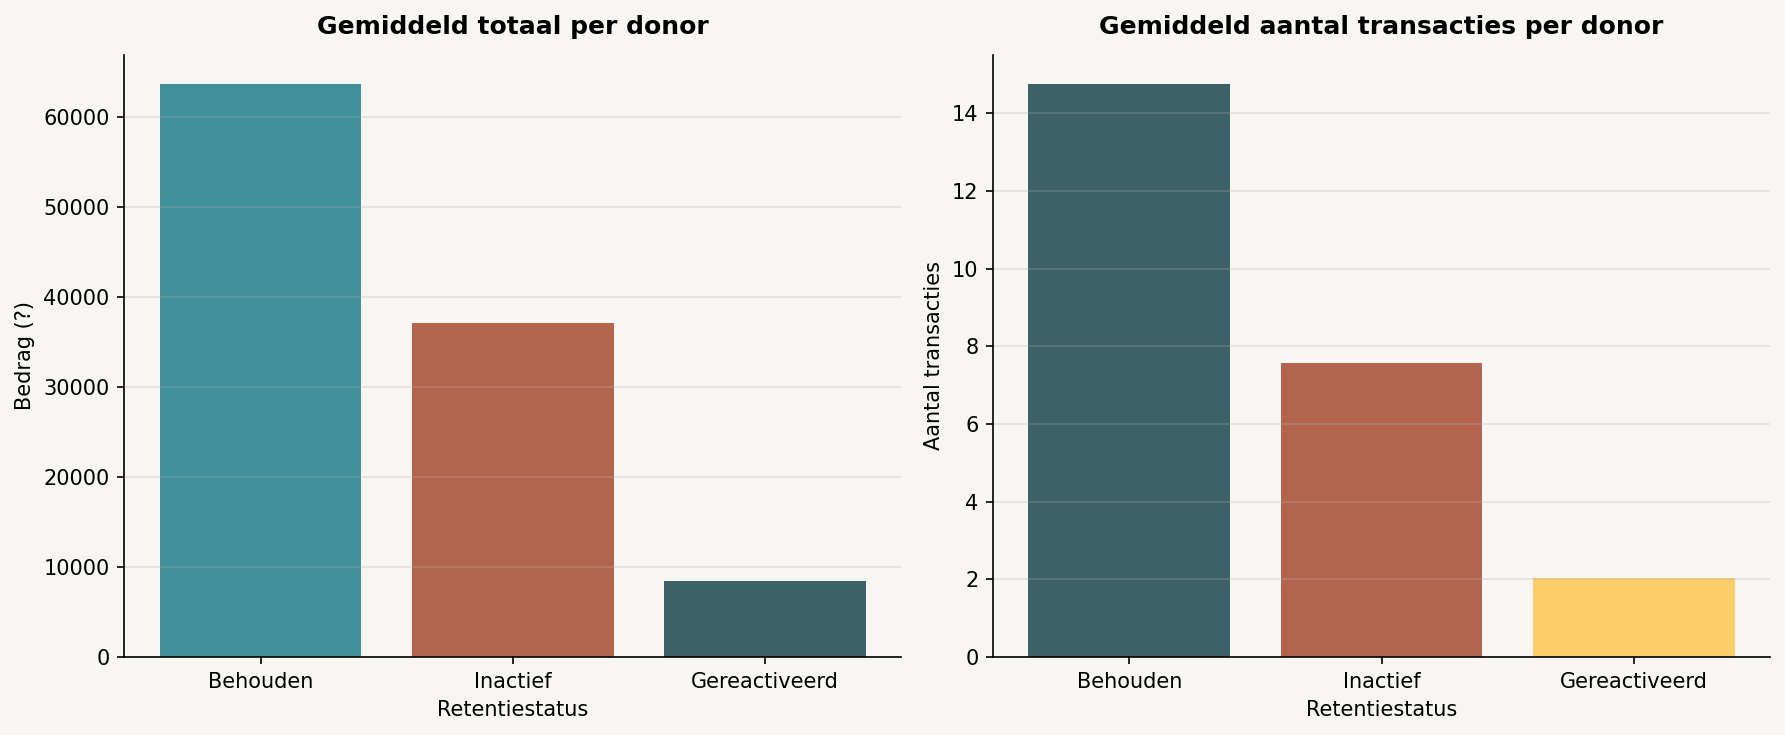

,gemiddeld_totaal_per_donor,mediaan_totaal_per_donor,gemiddeld_aantal_transacties
retention_status,,,
Retained,63708.62,2938.45,14.77
Lapsed,37107.85,1655.18,7.57
Reactivated,8477.01,560.60,2.04


In [15]:
ret_volgorde = ['Retained', 'Lapsed', 'Reactivated']
ret_nl = {'Retained': 'Behouden', 'Lapsed': 'Inactief', 'Reactivated': 'Gereactiveerd'}

per_donor_ret = df_verdieping.groupby(['constituent_id', 'retention_status']).agg(
    totaal_gegeven=('amount', 'sum'),
    aantal_transacties=('transaction_id', 'count'),
    gemiddelde_gift=('amount', 'mean')
).reset_index()

ret_summary = per_donor_ret.groupby('retention_status').agg(
    gemiddeld_totaal_per_donor=('totaal_gegeven', 'mean'),
    mediaan_totaal_per_donor=('totaal_gegeven', 'median'),
    gemiddeld_aantal_transacties=('aantal_transacties', 'mean')
).reindex(ret_volgorde).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar([ret_nl[x] for x in ret_summary.index], ret_summary['gemiddeld_totaal_per_donor'], color=KLEUREN[:3], alpha=0.85)
axes[0].set_title('Gemiddeld totaal per donor', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Retentiestatus')
axes[0].set_ylabel('Bedrag (?)')
axes[0].grid(axis='y', alpha=0.3)
for spine in ['top', 'right']:
    axes[0].spines[spine].set_visible(False)

axes[1].bar([ret_nl[x] for x in ret_summary.index], ret_summary['gemiddeld_aantal_transacties'], color=[KLEUREN[2], KLEUREN[1], KLEUREN[4]], alpha=0.85)
axes[1].set_title('Gemiddeld aantal transacties per donor', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Retentiestatus')
axes[1].set_ylabel('Aantal transacties')
axes[1].grid(axis='y', alpha=0.3)
for spine in ['top', 'right']:
    axes[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(EXPORT_DIR / 'vis8_retentie_donatiegedrag.png', dpi=150, bbox_inches='tight')
plt.show()

display(ret_summary)


Observaties:
- `Retained`-donateurs geven gemiddeld meer en doen vaker transacties.
- Daardoor lijken zij in deze dataset gemiddeld waardevoller.
- Dit is een nuttige invalshoek voor opvolging en behoud.


### Regionale verschillen

De dataset bevat ook een regionale variabele (`state`). 


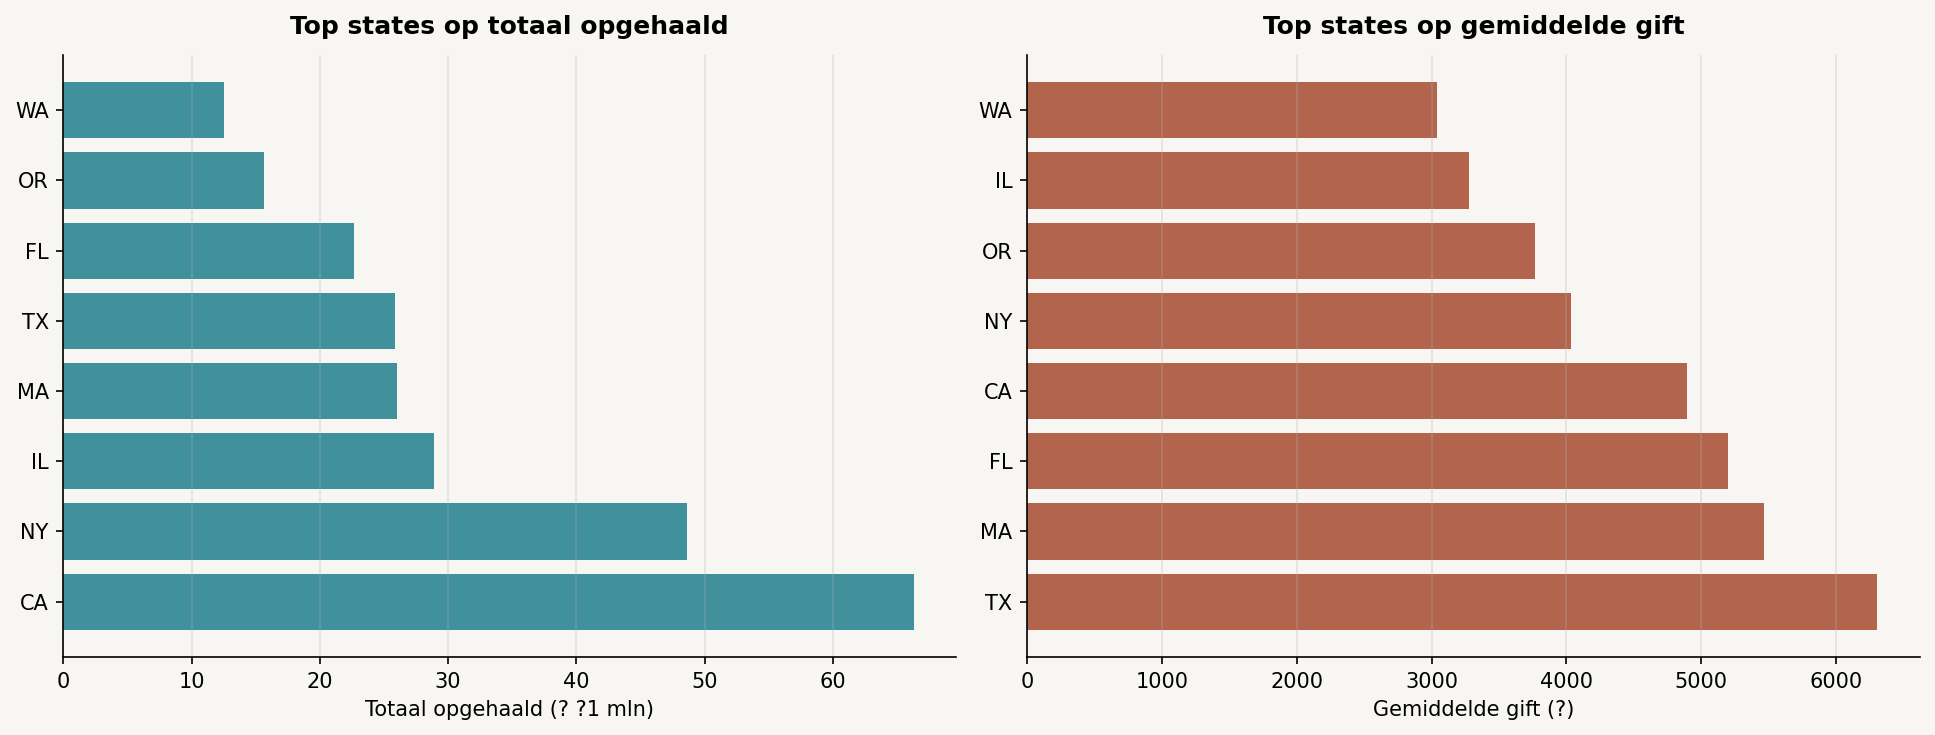

,transacties,unieke_donateurs,totaal,gemiddelde_gift
staat,,,,
CA,13543,1167,66309423.85,4896.21
NY,12054,968,48622958.20,4033.76
IL,8812,680,28888854.27,3278.35
MA,4762,392,26030975.09,5466.40
TX,4104,349,25886596.09,6307.65
FL,4362,365,22666368.27,5196.32
OR,4163,364,15671813.29,3764.55
WA,4109,341,12500147.58,3042.14


,transacties,unieke_donateurs,totaal,gemiddelde_gift
staat,,,,
TX,4104,349,25886596.09,6307.65
MA,4762,392,26030975.09,5466.40
FL,4362,365,22666368.27,5196.32
CA,13543,1167,66309423.85,4896.21
NY,12054,968,48622958.20,4033.76
OR,4163,364,15671813.29,3764.55
IL,8812,680,28888854.27,3278.35
WA,4109,341,12500147.58,3042.14


In [16]:
state_summary = df_verdieping.groupby('staat').agg(
    transacties=('transaction_id', 'count'),
    unieke_donateurs=('constituent_id', 'nunique'),
    totaal=('amount', 'sum'),
    gemiddelde_gift=('amount', 'mean')
).round(2)

state_top_totaal = state_summary.sort_values('totaal', ascending=False).head(8)
state_top_gem = state_summary[state_summary['transacties'] >= 200].sort_values('gemiddelde_gift', ascending=False).head(8)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(state_top_totaal.index, state_top_totaal['totaal'] / 1_000_000, color=KLEUREN[0], alpha=0.85)
axes[0].set_title('Top states op totaal opgehaald', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Totaal opgehaald (? ?1 mln)')
for spine in ['top', 'right']:
    axes[0].spines[spine].set_visible(False)
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(state_top_gem.index, state_top_gem['gemiddelde_gift'], color=KLEUREN[1], alpha=0.85)
axes[1].set_title('Top states op gemiddelde gift', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Gemiddelde gift (?)')
for spine in ['top', 'right']:
    axes[1].spines[spine].set_visible(False)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(EXPORT_DIR / 'vis9_state_donatiegedrag.png', dpi=150, bbox_inches='tight')
plt.show()

display(state_top_totaal)
display(state_top_gem)


Observaties:
- Ook tussen regio's zijn verschillen zichtbaar in totaalbedrag en gemiddelde gift.
- In een Nederlandse context zou je eerder naar regio of doelgroepsegment kijken.


## Conclusie

Deze verkennende analyse laat zien dat:
- organisaties geven in deze dataset gemiddeld grotere bedragen dan individuele donateurs
- hogere donor levels, vooral Principal, hangen samen met hogere giftbedragen
- Retained-donateurs geven gemiddeld meer en doen vaker transacties dan Lapsed en Reactivated donateurs
- betaalmethoden verschillen per type donateur, wat relevant kan zijn voor verwerking en rapportage

Samen laten deze uitkomsten zien dat niet alle donateurs hetzelfde gedrag laten zien. Segmentatie en eenvoudige rapportages kunnen hierom nuttig in fondsenwerving.

## Vervolg

Mogelijke vervolgstappen zijn:
- een eenvoudige Power BI-rapportage bouwen op basis van de exports
- extra validaties toevoegen op campagnes, betaalmethoden of communicatiegegevens
- een eenvoudige workflow uitwerken voor opvolging of signalering

In [17]:
df = pd.read_parquet(SILVER_DIR / 'transacties_verrijkt.parquet')
gold_campagne = pd.read_parquet(GOLD_DIR / 'gold_campagne.parquet')

print('=' * 60)
print('SAMENVATTING DONATEURSDATA')
print('=' * 60)

print(f'\nPeriode              : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Totaal transacties   : {len(df):,}')
print(f'Totaal opgehaald     : €{df["amount"].sum():,.0f}')
print(f'Unieke donateurs     : {df["constituent_id"].nunique():,}')
print(f'Gemiddelde donatie   : €{df["amount"].mean():,.2f}')
print(f'Mediaan donatie      : €{df["amount"].median():,.2f}')
print(f'Grootste donatie     : €{df["amount"].max():,.2f}')

print(f'\nAantal campagnes     : {df["campaign_id"].nunique()}')
beste = gold_campagne.iloc[0]
print(f'Beste campagne       : {beste["campagne_naam"]} (€{beste["totaal_donaties"]:,.0f})')

print(f'\nMeest gebruikte betaalmethode: {df["payment_method"].value_counts().index[0]}')

print()
print('Donorniveauverdeling:')
for niveau, n in df.groupby('donor_level')['constituent_id'].nunique().items():
    print(f'  {niveau:<12}: {n:,} donateurs')

print()
print('=' * 60)
print('EXPORTS')
print('=' * 60)
print(f'  Excel  : exports/wkof_rapportage.xlsx')
print(f'  Plots  : exports/vis1_*.png t/m vis4_*.png')
print(f'  Parquet: data/bronze/, data/silver/, data/gold/')
print('=' * 60)


SAMENVATTING DONATEURSDATA

Periode              : 2021-03-27 → 2025-05-27
Totaal transacties   : 55,909
Totaal opgehaald     : €246,577,137
Unieke donateurs     : 4,626
Gemiddelde donatie   : €4,410.33
Mediaan donatie      : €213.52
Grootste donatie     : €696,581.14

Aantal campagnes     : 24
Beste campagne       : Wildlands Corridor Acquisition (€51,513,053)

Meest gebruikte betaalmethode: Credit Card

Donorniveauverdeling:
  General     : 1,074 donateurs
  Major       : 872 donateurs
  Mid-level   : 1,936 donateurs
  Principal   : 744 donateurs

EXPORTS
  Excel  : exports/wkof_rapportage.xlsx
  Plots  : exports/vis1_*.png t/m vis4_*.png
  Parquet: data/bronze/, data/silver/, data/gold/
